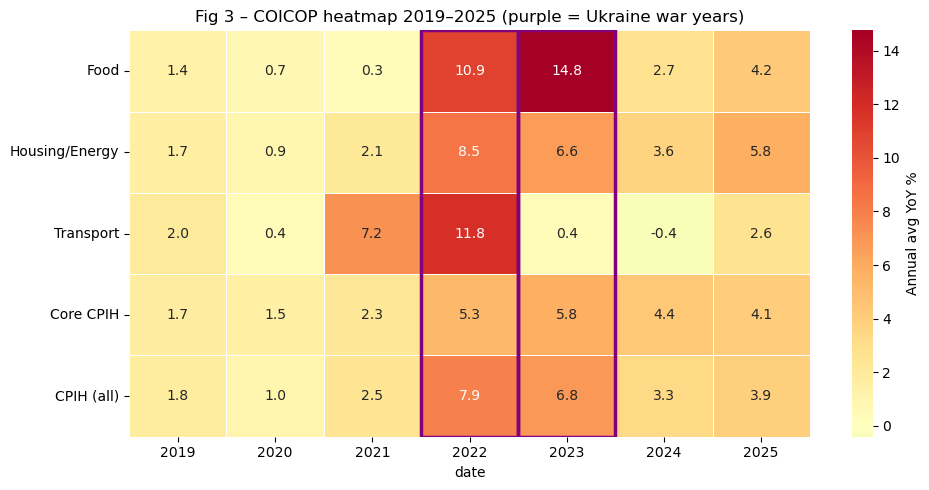

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("master_table_v2_uk_inflation_war_baseline_with_ppi.csv",
                 parse_dates=["date"], index_col="date")

coicop_cols = {
    "Food":           "food_yoy",
    "Housing/Energy": "housing_fuels_yoy",
    "Transport":      "transport_yoy",
    "Core CPIH":      "core_cpih_yoy",
    "CPIH (all)":     "cpih_yoy",
}

heat = df.loc["2019":"2025", list(coicop_cols.values())]
heat_annual = heat.resample("YE").mean()
heat_annual.index = heat_annual.index.year
heat_annual.columns = list(coicop_cols.keys())

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heat_annual.T, cmap="RdYlGn_r", center=0,
            annot=True, fmt=".1f", linewidths=0.4,
            ax=ax, cbar_kws={"label": "Annual avg YoY %"})

for col_idx, year in enumerate(heat_annual.index):
    if year in [2022, 2023]:
        ax.add_patch(plt.Rectangle(
            (col_idx, 0), 1, len(coicop_cols),
            fill=False, edgecolor="purple", lw=2.5))

ax.set(title="Fig 3 – COICOP heatmap 2019–2025 (purple = Ukraine war years)")
plt.tight_layout()
plt.savefig("fig3_coicop_heatmap.png", dpi=150)
plt.show()

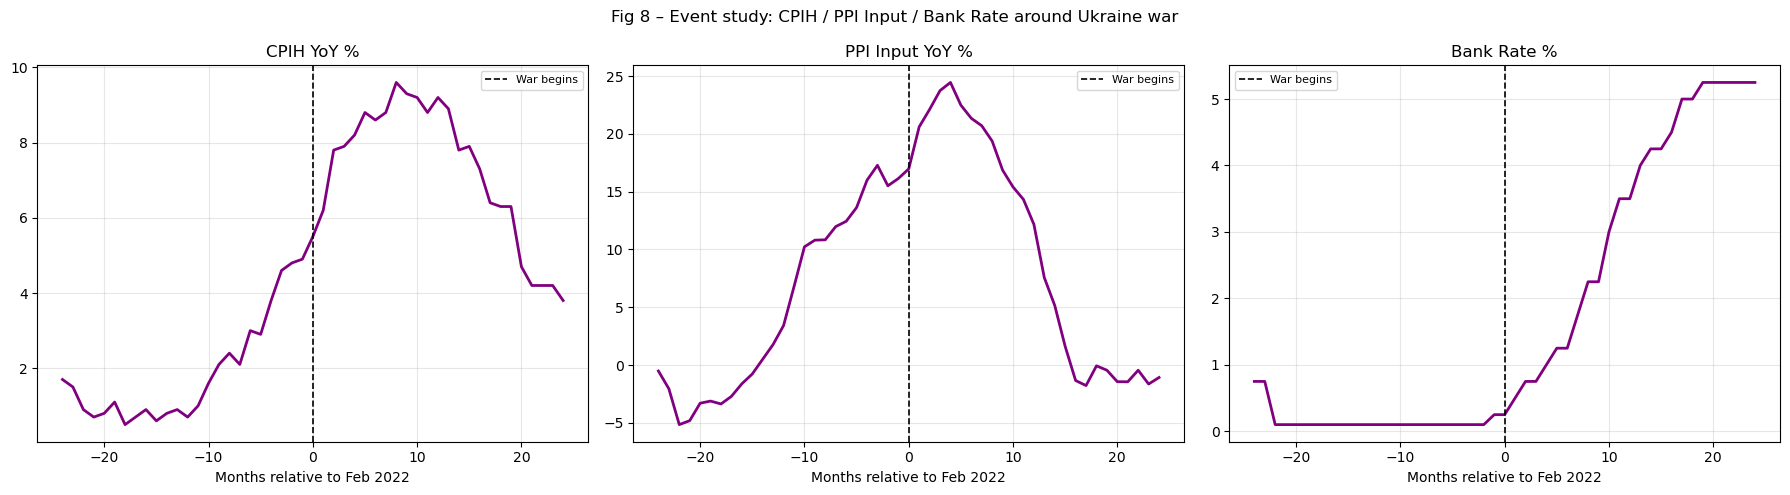

In [3]:
war_date = pd.Timestamp("2022-02-01")
window = 24

series_to_plot = {
    "CPIH YoY %":      "cpih_yoy",
    "PPI Input YoY %": "ppi_input_yoy",
    "Bank Rate %":     "bank_rate",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, col) in zip(axes, series_to_plot.items()):
    s = df[col].dropna()
    start = war_date - pd.DateOffset(months=window)
    end   = war_date + pd.DateOffset(months=window)
    window_data = s.loc[start:end].copy()
    window_data.index = range(-window, len(window_data) - window)

    ax.plot(window_data.index, window_data.values, color="purple", lw=2)
    ax.axvline(0, color="black", lw=1.2, ls="--", label="War begins")
    ax.set(title=title, xlabel="Months relative to Feb 2022")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle("Fig 8 – Event study: CPIH / PPI Input / Bank Rate around Ukraine war")
plt.tight_layout()
plt.savefig("fig8_event_study_panel.png", dpi=150)
plt.show()

Feature matrix: 195 rows × 60 features
               MAE_mean  MAE_std
Ridge             0.308    0.161
OLS               0.323    0.180
Random Forest     1.104    0.921


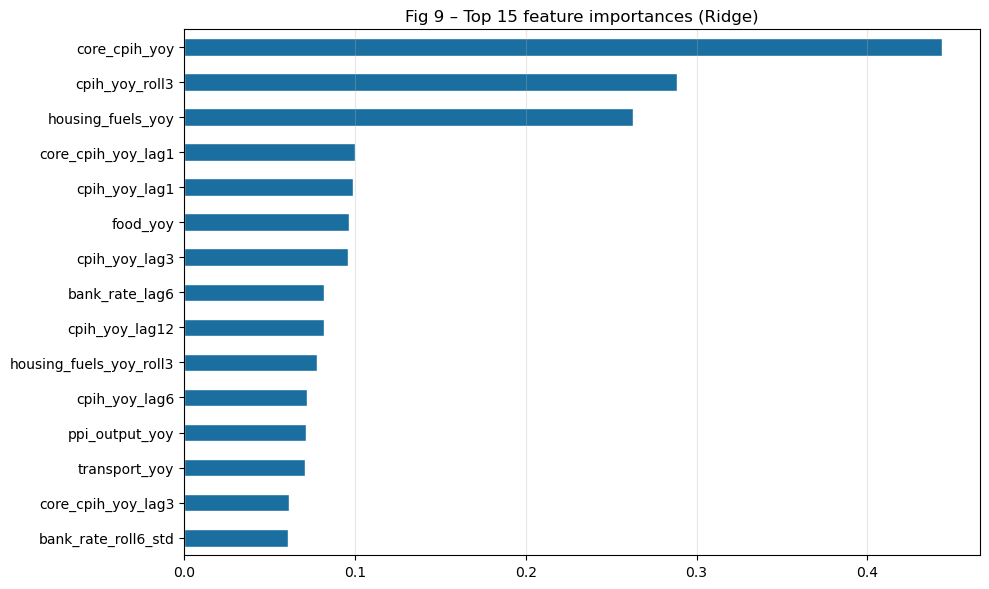

In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import warnings
warnings.filterwarnings("ignore")

def generate_features(df, target_col="cpih_yoy", lags=[1, 3, 6, 12]):
    feat = df.copy()

    feature_cols = ["cpih_yoy", "food_yoy", "housing_fuels_yoy",
                    "transport_yoy", "core_cpih_yoy",
                    "bank_rate", "ppi_input_yoy", "ppi_export_yoy"]

    for col in feature_cols:
        for lag in lags:
            feat[f"{col}_lag{lag}"] = df[col].shift(lag)
        feat[f"{col}_roll3"] = df[col].rolling(3).mean()
        feat[f"{col}_roll6_std"] = df[col].rolling(6).std()

    # Seasonality
    feat["month_sin"] = np.sin(2 * np.pi * df.index.month / 12)
    feat["month_cos"] = np.cos(2 * np.pi * df.index.month / 12)

    # war_dummy already in the data — keep it as a feature
    return feat.dropna()

features_df = generate_features(df)
X = features_df.drop(columns=["cpih_yoy", "date"] if "date" in features_df.columns else ["cpih_yoy"])
y = features_df["cpih_yoy"]

print(f"Feature matrix: {X.shape[0]} rows × {X.shape[1]} features")

# Model comparison
tscv = TimeSeriesSplit(n_splits=5)
models = {
    "OLS":           LinearRegression(),
    "Ridge":         Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=tscv,
                             scoring="neg_mean_absolute_error")
    results[name] = {"MAE_mean": round(-scores.mean(), 3),
                     "MAE_std":  round(scores.std(), 3)}

results_df = pd.DataFrame(results).T.sort_values("MAE_mean")
print(results_df)

# Feature importance plot (best model)
best_name = results_df.index[0]
best_model = models[best_name]
best_model.fit(X, y)

importances = (pd.Series(best_model.feature_importances_, index=X.columns)
               if hasattr(best_model, "feature_importances_")
               else pd.Series(np.abs(best_model.coef_), index=X.columns))

fig, ax = plt.subplots(figsize=(10, 6))
importances.sort_values().tail(15).plot(kind="barh", ax=ax,
                                         color="#1a6fa0", edgecolor="white")
ax.set(title=f"Fig 9 – Top 15 feature importances ({best_name})")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("fig9_feature_importance.png", dpi=150)
plt.show()

results_df.to_csv("model_comparison.csv")

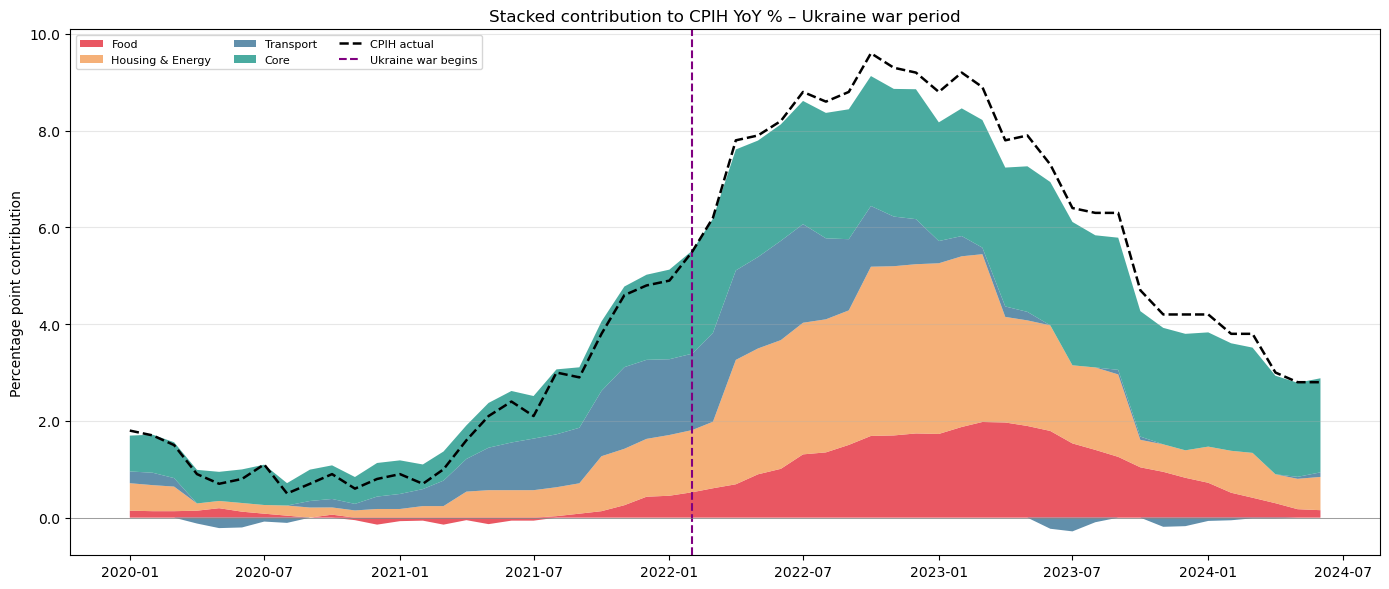

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df = pd.read_csv("master_table_v2_uk_inflation_war_baseline_with_ppi.csv",
                 parse_dates=["date"], index_col="date")

# ONS COICOP weights (approximate — adjust if your group has exact weights)
# These are the rough expenditure weights out of 1000
weights = {
    "food_yoy":           103,
    "housing_fuels_yoy":  299,
    "transport_yoy":      135,
    "core_cpih_yoy":      463,   # everything else
}

# Focus on the war window
plot_df = df.loc["2020-01":"2024-06"].copy()

# Calculate contribution = (weight / 1000) * category_yoy
contrib = pd.DataFrame(index=plot_df.index)
for col, weight in weights.items():
    contrib[col] = plot_df[col] * (weight / 1000)

contrib.columns = ["Food", "Housing & Energy", "Transport", "Core"]

# Plot
war_date = pd.Timestamp("2022-02-01")
colors = ["#e63946", "#f4a261", "#457b9d", "#2a9d8f"]

fig, ax = plt.subplots(figsize=(14, 6))

# Separate positive and negative contributions for proper stacking
contrib_pos = contrib.clip(lower=0)
contrib_neg = contrib.clip(upper=0)

ax.stackplot(contrib.index, contrib_pos.T, labels=contrib.columns,
             colors=colors, alpha=0.85)
ax.stackplot(contrib.index, contrib_neg.T, colors=colors, alpha=0.85)

# Overlay actual CPIH line
ax.plot(plot_df.index, plot_df["cpih_yoy"], color="black",
        lw=1.8, ls="--", label="CPIH actual", zorder=5)

ax.axvline(war_date, color="purple", lw=1.5, ls="--", label="Ukraine war begins")
ax.axhline(0, color="grey", lw=0.5)

ax.set(title="Stacked contribution to CPIH YoY % – Ukraine war period",
       ylabel="Percentage point contribution", xlabel="")
ax.legend(fontsize=8, ncol=3, loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f"))
plt.tight_layout()
plt.savefig("fig_stacked_contribution.png", dpi=150)
plt.show()

              precision    recall  f1-score   support

      Normal       0.75      1.00      0.86       111
   War shock       1.00      0.24      0.39        49

    accuracy                           0.77       160
   macro avg       0.88      0.62      0.63       160
weighted avg       0.83      0.77      0.72       160



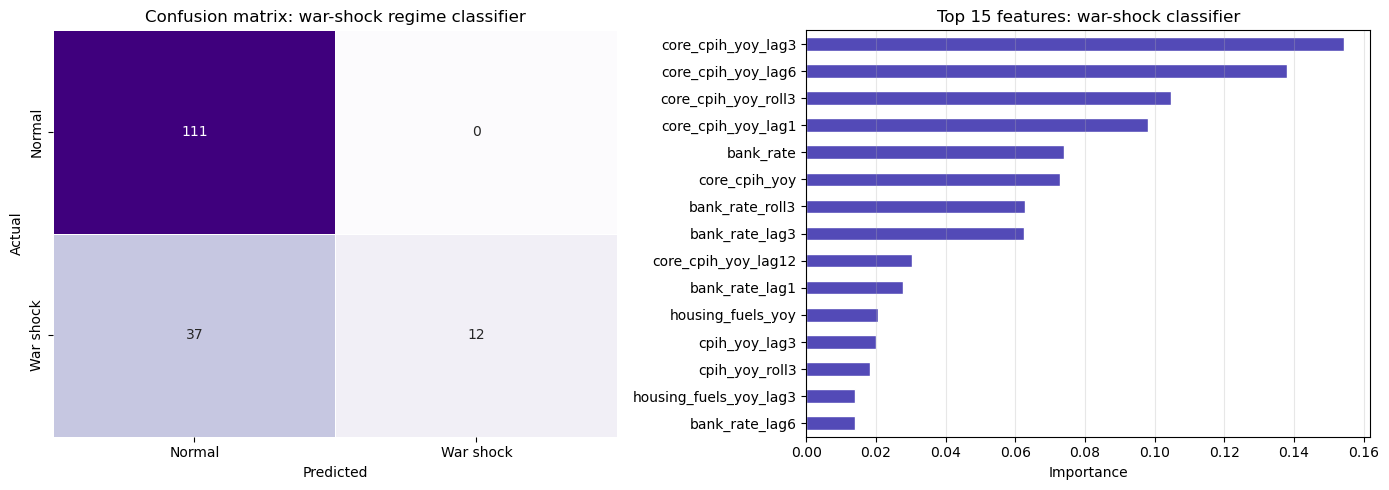

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Fix: ensure y is clean integers
y = features_df["war_dummy"].fillna(0).astype(int)
X = features_df.drop(columns=["cpih_yoy", "war_dummy"])

clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
tscv = TimeSeriesSplit(n_splits=5)

# Manually collect predictions across folds
y_pred = np.full(len(y), -1)

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    clf.fit(X_train, y_train)
    y_pred[test_idx] = clf.predict(X_test)

# Only evaluate rows that were actually predicted
mask = y_pred != -1
y_eval = y.values[mask]
y_pred_eval = y_pred[mask]

# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_eval, y_pred_eval)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Normal", "War shock"],
            yticklabels=["Normal", "War shock"],
            ax=axes[0], cbar=False, linewidths=0.5)
axes[0].set(title="Confusion matrix: war-shock regime classifier",
            xlabel="Predicted", ylabel="Actual")

print(classification_report(y_eval, y_pred_eval,
                            target_names=["Normal", "War shock"]))

# ── Feature importance ────────────────────────────────────────────────────────
clf.fit(X, y)
importances = pd.Series(clf.feature_importances_, index=X.columns)
importances.sort_values().tail(15).plot(
    kind="barh", ax=axes[1], color="#534AB7", edgecolor="white")
axes[1].set(title="Top 15 features: war-shock classifier",
            xlabel="Importance")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("fig_confusion_matrix_feature_importance.png", dpi=150)
plt.show()

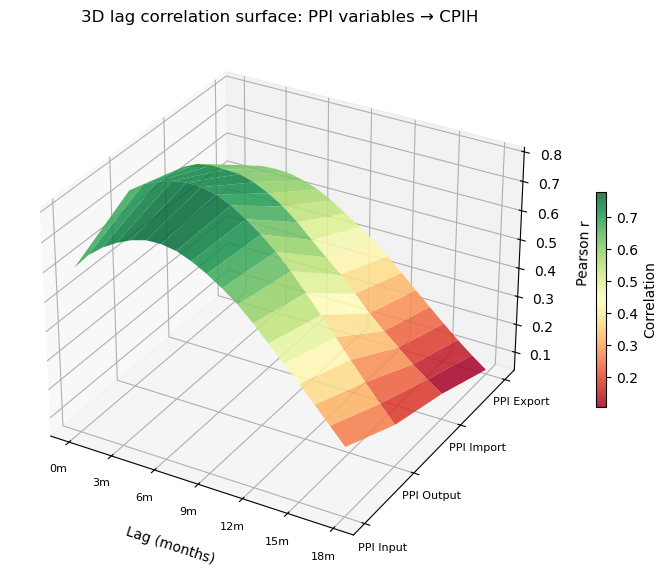

In [8]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt

ppi_vars = {
    "PPI Input":  "ppi_input_yoy",
    "PPI Output": "ppi_output_yoy",
    "PPI Import": "ppi_import_yoy",
    "PPI Export": "ppi_export_yoy",
}

max_lag = 18
lags = list(range(0, max_lag + 1))
var_names = list(ppi_vars.keys())

# Build correlation matrix: rows = PPI variables, cols = lags
corr_matrix = np.zeros((len(ppi_vars), len(lags)))

for i, (name, col) in enumerate(ppi_vars.items()):
    for j, lag in enumerate(lags):
        temp = pd.DataFrame({
            "cpih": df["cpih_yoy"],
            "ppi":  df[col].shift(lag)
        }).dropna()
        if len(temp) > 10:
            r, _ = pearsonr(temp["cpih"], temp["ppi"])
            corr_matrix[i, j] = r

# Plot
X_grid, Y_grid = np.meshgrid(lags, range(len(var_names)))

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(X_grid, Y_grid, corr_matrix,
                       cmap="RdYlGn", alpha=0.85, edgecolor="none")

ax.set_xticks(lags[::3])
ax.set_xticklabels([f"{l}m" for l in lags[::3]], fontsize=8)
ax.set_yticks(range(len(var_names)))
ax.set_yticklabels(var_names, fontsize=8)
ax.set_xlabel("Lag (months)", labelpad=10)
ax.set_ylabel("")
ax.set_zlabel("Pearson r", labelpad=8)
ax.set_title("3D lag correlation surface: PPI variables → CPIH")

fig.colorbar(surf, ax=ax, shrink=0.4, label="Correlation")
plt.tight_layout()
plt.savefig("fig_3d_lag_surface.png", dpi=150)
plt.show()

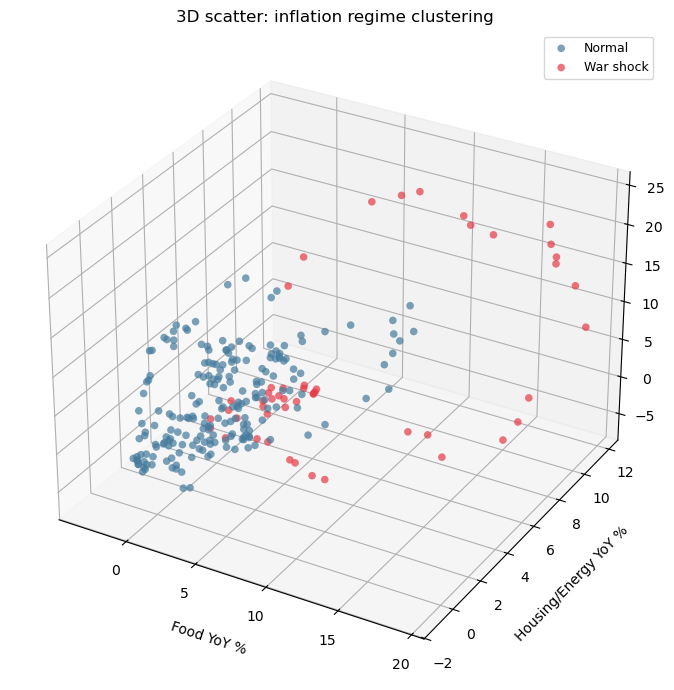

In [9]:
from mpl_toolkits.mplot3d import Axes3D

plot_df = df[["food_yoy", "housing_fuels_yoy", 
              "ppi_input_yoy", "war_dummy"]].dropna()

colors = plot_df["war_dummy"].map({0: "#457b9d", 1: "#e63946"})
labels = plot_df["war_dummy"].map({0: "Normal", 1: "War shock"})

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")

for regime, col, label in [(0, "#457b9d", "Normal"), 
                            (1, "#e63946", "War shock")]:
    mask = plot_df["war_dummy"] == regime
    ax.scatter(plot_df.loc[mask, "food_yoy"],
               plot_df.loc[mask, "housing_fuels_yoy"],
               plot_df.loc[mask, "ppi_input_yoy"],
               c=col, label=label, alpha=0.7, s=30, edgecolors="none")

ax.set_xlabel("Food YoY %", labelpad=10)
ax.set_ylabel("Housing/Energy YoY %", labelpad=10)
ax.set_zlabel("PPI Input YoY %", labelpad=8)
ax.set_title("3D scatter: inflation regime clustering")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig_3d_scatter_clustering.png", dpi=150)
plt.show()

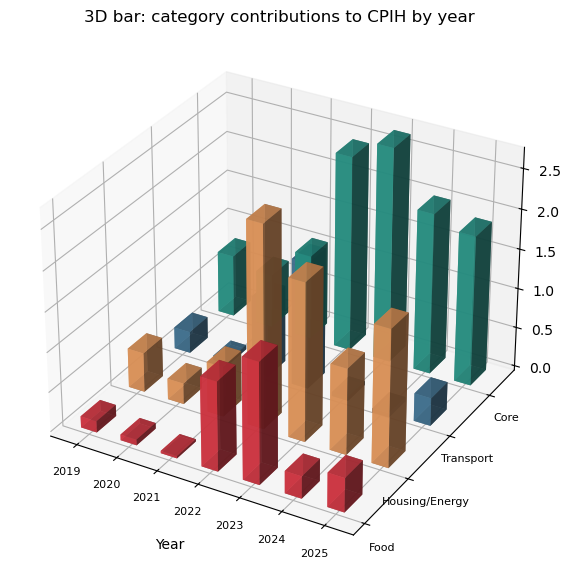

In [10]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

contrib_cols = {
    "Food":           ("food_yoy",           103),
    "Housing/Energy": ("housing_fuels_yoy",  299),
    "Transport":      ("transport_yoy",       135),
    "Core":           ("core_cpih_yoy",       463),
}

# Annual average contributions
years = list(range(2019, 2026))
categories = list(contrib_cols.keys())
colors = ["#e63946", "#f4a261", "#457b9d", "#2a9d8f"]

contrib_data = np.zeros((len(categories), len(years)))
for i, (cat, (col, weight)) in enumerate(contrib_cols.items()):
    annual = df[col].resample("YE").mean()
    for j, yr in enumerate(years):
        if yr in annual.index.year:
            contrib_data[i, j] = annual[annual.index.year == yr].values[0] * (weight / 1000)

fig = plt.figure(figsize=(13, 7))
ax = fig.add_subplot(111, projection="3d")

x_pos = np.arange(len(years))
bar_width = 0.4
bar_depth = 0.4

for i, (cat, col) in enumerate(zip(categories, colors)):
    ax.bar3d(x_pos, i, np.zeros(len(years)),
             bar_width, bar_depth, contrib_data[i],
             color=col, alpha=0.8, label=cat)

ax.set_xticks(x_pos + bar_width / 2)
ax.set_xticklabels(years, fontsize=8)
ax.set_yticks(range(len(categories)))
ax.set_yticklabels(categories, fontsize=8)
ax.set_xlabel("Year", labelpad=10)
ax.set_ylabel("")
ax.set_zlabel("Contribution (pp)", labelpad=8)
ax.set_title("3D bar: category contributions to CPIH by year")
plt.tight_layout()
plt.savefig("fig_3d_bar_contributions.png", dpi=150)
plt.show()